In [1]:
import pandas as pd
import numpy as np
import os
from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties, fontManager
from matplotlib.patches import Rectangle
import matplotlib.colors as mcolors
import matplotlib.path as mpath
import matplotlib.patches as mpatches

font_path = "/usr/share/fonts/myFonts/arial.ttf"
fontManager.addfont(font_path)
font_prop = FontProperties(fname=font_path)
font_name = font_prop.get_name()
plt.rcParams["font.family"] = [font_name]
plt.rcParams.update({
    "font.size": 7,
    "axes.titlesize": 8,
    "axes.labelsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 6.5,
})

def identity_to_color(base_hex, identity, ID_MIN=70, ID_MAX=100):
    FIXED_ALPHA = 0.8
    identity = np.clip(identity, ID_MIN, ID_MAX)
    ratio = (identity - ID_MIN) / (ID_MAX - ID_MIN)
    base_rgb = np.array(mcolors.hex2color(base_hex))
    start_rgb = (np.array([1.0, 1.0, 1.0]) * 2/3) + (base_rgb * 1/3)
    final_rgb = start_rgb * (1 - ratio) + base_rgb * ratio
    return (*final_rgb, FIXED_ALPHA)

def plot_synteny_blocks(ax, df, s1_line, s2_line, BASE_NORMAL="#bbbbbb", BASE_CROSS="#73a9c2", ID_MIN=70, ID_MAX=100, FIXED_ALPHA=0.5):
    s1_x_data = s1_line[0].get_xdata()
    s1_y_data = s1_line[0].get_ydata()

    s1_x_start = s1_x_data[0]
    s1_x_end   = s1_x_data[1]
    s1_y       = s1_y_data[0]

    s2_x_data = s2_line[0].get_xdata()
    s2_y_data = s2_line[0].get_ydata()

    s2_x_start = s2_x_data[0]
    s2_x_end   = s2_x_data[1]
    s2_y       = s2_y_data[0]
    
    def draw_single_band(s1_start, s1_end, s2_start, s2_end, identity):
        mid_y = (s1_y + s2_y) / 2
        dir_s1 = s1_end > s1_start
        dir_s2 = s2_end > s2_start
        is_cross = dir_s1 != dir_s2

        base = BASE_CROSS if is_cross else BASE_NORMAL
        color = identity_to_color(base, identity, ID_MIN=ID_MIN, ID_MAX=ID_MAX)

        verts = [
            (s1_start + s1_x_start, s1_y),
            (s1_start + s1_x_start, mid_y),
            (s2_start + s2_x_start, mid_y),
            (s2_start + s2_x_start, s2_y),
        
            (s2_end   + s2_x_start, s2_y),
            (s2_end   + s2_x_start, mid_y),
            (s1_end   + s1_x_start, mid_y),
            (s1_end   + s1_x_start, s1_y),
        
            (s1_start + s1_x_start, s1_y)
        ]
        
        codes = [
            mpath.Path.MOVETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO,
            mpath.Path.LINETO, mpath.Path.CURVE4, mpath.Path.CURVE4, mpath.Path.LINETO, mpath.Path.CLOSEPOLY
        ]
        patch = mpatches.PathPatch(mpath.Path(verts, codes), facecolor=color, edgecolor="none")
        ax.add_patch(patch)

    for _, row in df.iterrows():
        draw_single_band(
            row["qstart"], row["qend"],
            row["sstart"], row["send"],
            row["pident"]
        )

def sequence_alignment(query_acc, sub_acc, contig_dict, ident_thr=90, len_thr=5000):
    for acc_n in [query_acc, sub_acc]:
        handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
        acc_record = SeqIO.parse(handle, 'genbank')
        os.chdir('/active-data/temp')
        temp_ncl_file = open(f'temp_nucleotide_seq-{acc_n}.fasta', 'w+')
        for seq_record in acc_record:
            if seq_record.id in contig_dict[acc_n]:
                SeqIO.write(seq_record, temp_ncl_file, "fasta")
        temp_ncl_file.close()
        handle.close()
    
    os.chdir('/active-data/temp')
    %time os.system(f'blastn -query temp_nucleotide_seq-{query_acc}.fasta -subject temp_nucleotide_seq-{sub_acc}.fasta -out blastn_results.txt -evalue 1e-50 -max_target_seqs 100000 -outfmt 6')
    head = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
    align_result = pd.read_csv('blastn_results.txt', sep = '\t', engine = 'python', header = None, names = head)
    align_result = align_result[(align_result['pident'] >= ident_thr) & (align_result['length'] >= len_thr)].reset_index(drop=True)
    os.system(f'rm temp_nucleotide_seq-{query_acc}.fasta')
    os.system(f'rm temp_nucleotide_seq-{sub_acc}.fasta')
    return align_result

def sequence_len(contig_dict):
    len_dict = {}
    for acc_n in contig_dict:
        handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
        acc_record = SeqIO.parse(handle, 'genbank')
        for seq_record in acc_record:
            if seq_record.id in contig_dict[acc_n]:
                len_dict[seq_record.id] = len(seq_record)
        handle.close()
    return len_dict

def draw_colorbar_legend(ax, rel_x=0.80, rel_y=0.85, width=0.02, height=0.25, gap=0.01, ID_MIN=70, ID_MAX=100):
    n_steps = 50
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    data_w = x1 - x0
    data_h = y1 - y0

    x_start = x0 + rel_x * data_w
    y_top = y0 + rel_y * data_h
    y_bottom = y_top - height * data_h

    x1_left = x_start
    x1_right = x_start + width * data_w
    x2_left = x1_right + gap * data_w
    x2_right = x2_left + width * data_w

    ys = np.linspace(y_top, y_bottom, n_steps)
    dy = ys[1] - ys[0]

    BASE_NORMAL = "#bbbbbb"
    BASE_CROSS  = "#73a9c2"

    for i in range(n_steps):
        id_val = ID_MAX - (ID_MAX - ID_MIN) * (i / (n_steps - 1))
        c1 = identity_to_color(BASE_NORMAL, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        c2 = identity_to_color(BASE_CROSS, id_val, ID_MIN=ID_MIN, ID_MAX=ID_MAX)
        ax.fill_between([x1_left, x1_right], ys[i], ys[i]+dy, color=c1, ec="none")
        ax.fill_between([x2_left, x2_right], ys[i], ys[i]+dy, color=c2, ec="none")

    ax.plot([x1_left, x1_right, x1_right, x1_left, x1_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)
    ax.plot([x2_left, x2_right, x2_right, x2_left, x2_left], [y_bottom, y_bottom, y_top, y_top, y_bottom], c="k", lw=1)

    mid_x = (x1_left + x2_right) / 2
    ax.text(mid_x, y_top + 0.35, "Identity", ha="center", va="bottom")
    ax.text(mid_x, y_top + 0.02, f"{ID_MAX}%", ha="center", va="bottom")
    ax.text(mid_x, y_bottom - 0.05, f"{ID_MIN}%", ha="center", va="top")

def add_length_bar(ax, x_start = 5.45e6, y_pos = 0.5, bar_length=2000):
    ax.plot([x_start, x_start + bar_length], [y_pos, y_pos], color='black', lw=1)
    ax.plot([x_start, x_start], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.plot([x_start+bar_length, x_start+bar_length], [y_pos-0.05, y_pos+0.05], color='black', lw=1)
    ax.text(x_start + bar_length/2, y_pos - 0.12, f'{bar_length} bp', ha='center', va='top')

def get_align_results(acc_list, contig_dict):
    all_result = []
    for i in range(len(acc_list) - 1):
        query_acc = acc_list[i]
        sub_acc = acc_list[i+1]
        align_result = sequence_alignment(query_acc, sub_acc, contig_dict)
        all_result.append(align_result)
    return pd.concat(all_result, ignore_index=True)

In [2]:
def pair_sequence_alignment(query_acc, sub_acc, contig_dict):
    len_add = {}
    for acc_n in [query_acc, sub_acc]:
        handle = open(f'/active-data/genomes/bacteria_complete_annotationRefSeq-20250807/data/{acc_n}/genomic.gbff')
        acc_record = SeqIO.parse(handle, 'genbank')
        os.chdir('/active-data/temp')
        temp_ncl_file = open(f'temp_nucleotide_seq-{acc_n}.fasta', 'w+')
        sum_len = 0
        len_add[acc_n] = {}
        for seq_record in acc_record:
            if seq_record.id not in contig_dict[acc_n]:
                continue
            SeqIO.write(seq_record, temp_ncl_file, "fasta")
            len_add[acc_n][seq_record.id] = sum_len
            sum_len += len(seq_record)
        len_add[acc_n]['all'] = sum_len
        temp_ncl_file.close()
        handle.close()
    
    os.chdir('/active-data/temp')
    %time os.system(f'blastn -query temp_nucleotide_seq-{query_acc}.fasta -subject temp_nucleotide_seq-{sub_acc}.fasta -out blastn_results.txt -evalue 1e-50 -max_target_seqs 100000 -outfmt 6')
    head = ['qseqid', 'sseqid', 'pident', 'length', 'mismatch', 'gapopen', 'qstart', 'qend', 'sstart', 'send', 'evalue', 'bitscore']
    align_result = pd.read_csv('blastn_results.txt', sep = '\t', engine = 'python', header = None, names = head)
    align_result = align_result[(align_result['pident'] >= 90) & (align_result['length'] >= 5000)].reset_index(drop=True)
    os.system(f'rm temp_nucleotide_seq-{query_acc}.fasta')
    os.system(f'rm temp_nucleotide_seq-{sub_acc}.fasta')

    return align_result, len_add
    
    
def plot_alignment(ax, align_result, query_acc, sub_acc, len_add):
    for i in range(len(align_result)):
        q_start = align_result['qstart'][i] + len_add[query_acc][align_result['qseqid'][i]]
        q_end   = align_result['qend'][i]   + len_add[query_acc][align_result['qseqid'][i]]
        s_start = align_result['sstart'][i] + len_add[sub_acc][align_result['sseqid'][i]]
        s_end   = align_result['send'][i]   + len_add[sub_acc][align_result['sseqid'][i]]
        
        ax.plot([q_start, q_end], [s_start, s_end], color='blue', lw=1)

    for item in len_add[query_acc]:
        if len_add[query_acc][item] != 0 and item != 'all':
            ax.axvline(x=len_add[query_acc][item] + 0.5, color='red', linestyle='--', alpha=0.2)

    for item in len_add[sub_acc]:
        if len_add[sub_acc][item] != 0 and item != 'all':
            ax.axhline(y=len_add[sub_acc][item] + 0.5, color='red', linestyle='--', alpha=0.2)

    ax.set_xlim(0, len_add[query_acc]['all'] + 1)
    ax.set_ylim(0, len_add[sub_acc]['all'] + 1)
    ax.set_xlabel(f'{query_acc} (bp)')
    ax.set_ylabel(f'{sub_acc} (bp)')
    
    #ax.grid(True, linestyle='--', alpha=0.2)
    legend_elements = [
        Line2D([0], [0], color='blue', lw=1, label='Matched regions'),
        Line2D([0], [0], color='red', linestyle='--', alpha=0.2, label='Replicon separator'),
    ]
    ax.legend(handles=legend_elements, loc='best', frameon=True)

In [3]:
acc_list = ['GCF_022569795.1', 'GCF_013340825.1', 'GCF_030389775.1', 'GCF_021484785.1', 'GCF_034643255.1', 'GCF_047946685.1']
contig_dict = {'GCF_022569795.1': ['NZ_CP093011.1'], 'GCF_021484785.1': ['NZ_CP090611.1', 'NZ_CP090612.1'], 
               'GCF_013340825.1': ['NZ_AP023205.1', 'NZ_AP023206.1', 'NZ_AP023209.1'], 'GCF_030389775.1': ['NZ_CP128950.1', 'NZ_CP128951.1'],
               'GCF_034643255.1': ['NZ_CP141084.1', 'NZ_CP141085.1', 'NZ_CP141086.1'],
               'GCF_047946685.1': ['NZ_CP159529.1', 'NZ_CP159530.1', 'NZ_CP159531.1']
              }
len_dict = sequence_len(contig_dict)
align_result = get_align_results(acc_list, contig_dict)

CPU times: user 0 ns, sys: 381 μs, total: 381 μs
Wall time: 2.77 s
CPU times: user 497 μs, sys: 26 μs, total: 523 μs
Wall time: 2.6 s
CPU times: user 394 μs, sys: 0 ns, total: 394 μs
Wall time: 3.7 s
CPU times: user 349 μs, sys: 0 ns, total: 349 μs
Wall time: 2.48 s
CPU times: user 0 ns, sys: 591 μs, total: 591 μs
Wall time: 3.83 s


In [4]:
query_acc_pair, sub_acc_pair = 'GCF_013340825.1', 'GCF_022569795.1'
pair_align_result, len_add = pair_sequence_alignment(query_acc_pair, sub_acc_pair, contig_dict)

CPU times: user 304 μs, sys: 16 μs, total: 320 μs
Wall time: 2.67 s


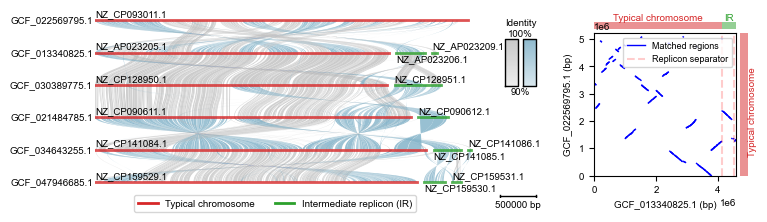

In [5]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(7.5, 7.5))

ax = fig.add_axes([0.115, 0.75, 0.6, 0.25])

lines = {}
gap_len = 100000
for i in range(len(acc_list)):
    acc = acc_list[i]
    site = 0
    y_site = len(acc_list) - i - 1 + 0.5
    ax.text(site-gap_len/3, y_site, acc, ha='right', va='center')
    for j in range(len(contig_dict[acc])):
        space = 0.2
        contig = contig_dict[acc][j]
        if len_dict[contig] > 4e6:
            color = plt.cm.tab10(3)
        else:
            color = plt.cm.tab10(2)
        lines[f'{acc}-{contig}'] = ax.plot([site, len_dict[contig] + site], [y_site, y_site], lw=2, c=color, alpha=0.8)
        if len(contig_dict[acc])>2:
            ax.text(site, y_site + space - space*2*(j%2), contig, va='center')
        else:
            ax.text(site, y_site + space, contig, va='center')
        site += gap_len + len_dict[contig]

legend_elements = [
    Line2D([0], [0], color=plt.cm.tab10(3), lw=2, label='Typical chromosome'),
    Line2D([0], [0], color=plt.cm.tab10(2),  lw=2, label='Intermediate replicon (IR)')
]

for i in range(len(acc_list) - 1):
    query_acc = acc_list[i]
    sub_acc = acc_list[i+1]

    for s1 in contig_dict[query_acc]:
        y1_site = 1.5 + i
        s1_line = lines[f'{query_acc}-{s1}']
        for s2 in contig_dict[sub_acc]:
            y2_site = 0.5 + i
            s2_line = lines[f'{sub_acc}-{s2}']
            plot_synteny_blocks(ax, align_result[(align_result['qseqid'] == s1) & (align_result['sseqid'] == s2)], s1_line, s2_line, ID_MIN=90)

ax.set_xlim(-10, 6.3e6)
ax.set_ylim(0, len(acc_list)-0.2)
draw_colorbar_legend(ax, rel_x=0.91, width=0.03, ID_MIN=90)
add_length_bar(ax, x_start = 6.3e6*0.9, y_pos = 0.05, bar_length=500000)
ax.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.4, -0.1), fontsize=7, frameon=True, ncol=2)
ax.axis("off")

ax_pair_x = 0.78
ax_pair_y = 0.78
ax_pair_size = 0.19
ax_pair = fig.add_axes([ax_pair_x, ax_pair_y, ax_pair_size, ax_pair_size])
plot_alignment(ax_pair, pair_align_result, query_acc_pair, sub_acc_pair, len_add)
# ax_pair.set_title('Two-genome comparison', pad=1)

ax_pair_gap = 0.005
ax_pair_bar_width = 0.01
ax_pair_x_bar = fig.add_axes([ax_pair_x, ax_pair_y + ax_pair_size + ax_pair_gap, ax_pair_size, ax_pair_bar_width], zorder=-1)
ax_pair_x_bar.add_patch(plt.Rectangle((0, 0), 
                                      len_dict[contig_dict[query_acc_pair][0]]/len_add[query_acc_pair]['all'], 1, linewidth=0,
                                      color=plt.cm.tab10(3), alpha=0.5))
ax_pair_x_bar.text(len_dict[contig_dict[query_acc_pair][0]]/len_add[query_acc_pair]['all']/2, 1, 'Typical chromosome', ha='center', va='bottom', color=plt.cm.tab10(3))
ax_pair_x_bar.add_patch(plt.Rectangle((len_dict[contig_dict[query_acc_pair][0]]/len_add[query_acc_pair]['all'], 0), 
                                      1-len_dict[contig_dict[query_acc_pair][0]]/len_add[query_acc_pair]['all'], 1, linewidth=0,
                                      color=plt.cm.tab10(2), alpha=0.5))
ax_pair_x_bar.text(len_dict[contig_dict[query_acc_pair][0]]/len_add[query_acc_pair]['all'] + 
                   (1-len_dict[contig_dict[query_acc_pair][0]]/len_add[query_acc_pair]['all'])/2, 1, 
                   'IR', ha='center', va='bottom', color=plt.cm.tab10(2))
ax_pair_x_bar.axis("off")

ax_pair_y_bar = fig.add_axes([ax_pair_x + ax_pair_size + ax_pair_gap, ax_pair_y, ax_pair_bar_width, ax_pair_size], zorder=-1)
ax_pair_y_bar.add_patch(plt.Rectangle((0, 0), 
                                      1, len_dict[contig_dict[sub_acc_pair][0]]/len_add[sub_acc_pair]['all'], linewidth=0,
                                      color=plt.cm.tab10(3), alpha=0.5))
ax_pair_y_bar.text(1.1, len_dict[contig_dict[query_acc_pair][0]]/len_add[query_acc_pair]['all']/2, 'Typical chromosome', ha='left', va='center', color=plt.cm.tab10(3), rotation=90)
ax_pair_y_bar.axis("off")


genus_name = 'Escherichia'
base_folder = f'/active-data/analysis_results/chr_pla/genus'
figure_fold = f'{base_folder}/figures'
os.makedirs(figure_fold, exist_ok=True)
os.chdir(figure_fold)
plt.savefig(f"{genus_name}_sequence_exchange_example1.svg", bbox_inches="tight", transparent=True)
plt.savefig(f"{genus_name}_sequence_exchange_example1.png", dpi=1000, bbox_inches="tight", transparent=True)

#fig.patches.append(Rectangle((0,0),1,1,transform=fig.transFigure,fill=False,lw=2))
plt.show()